### 6.1 (unchecked)

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   

(530, 530)

N = 280900 min = 1507, max = 15752, mean = 4795.924268422927, std = 1848.2558984219054
Mode of the data: 3551
Median of the data: 4102.0


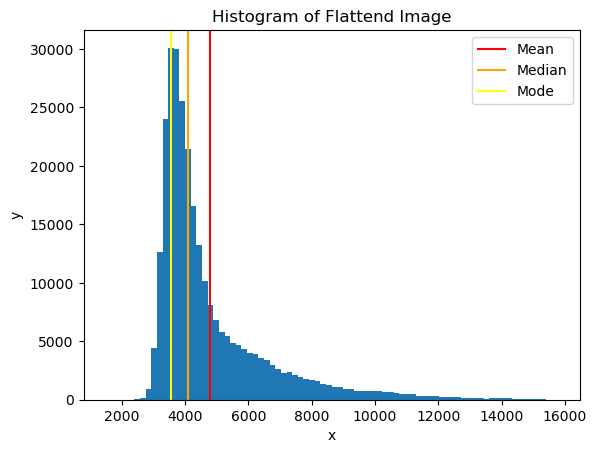

 [astropy.io.fits.verify]


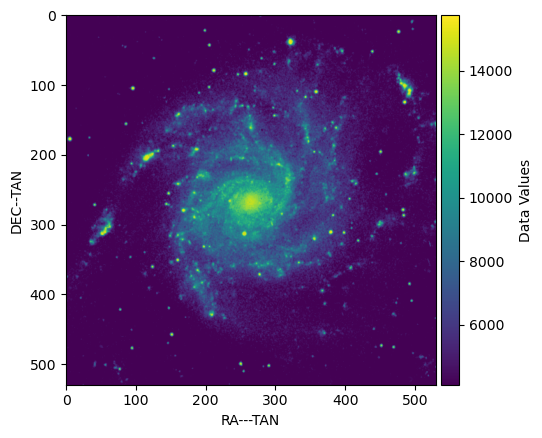

In [1]:
from astropy.io import fits
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Opening file and getting the info
hdulist = fits.open('m101.fits')
hdulist.info()

# Amount of HDU's: 2
# The first HDU contains the image data; it has got index 0
# The numbertype is int16

# First 5 keywords: Name, Ver, Type, Cards, Dimensions. 
info = hdulist[0].header
print()
# BITPIX is 16, this coincides with the numbertype

# Reading the data
dat = hdulist[0].data
print(dat.shape)  # Shape is (530, 530)
# The shape is also given with info, and NAXIS also tells us the amount of dimensions which indeed is 2

# The attribute of dytpe is: ('>i2'), 16 bit (2 Byte) images
dt = dat.dtype
print()

# dytpe tells how the data is stored. It gives the same answer as BITPIX, but in a different way. It gives us the size of the pixels

# Statistical info:
flatdat = dat.flatten()
nobs, (minval, maxval), mean, var, skew, kurt = stats.describe(flatdat)
print(f"N = {nobs} min = {minval}, max = {maxval}, mean = {mean}, std = {var**0.5}")
mode, counts = stats.mode(flatdat)
print(f"Mode of the data: {mode}")
median = np.median(dat.flat)
print(f"Median of the data: {median}")

# Plotting histogram
fig, ax = plt.subplots()
ax.hist(flatdat, bins = 80)
ax.axvline(mean, c = 'red', label = 'Mean')
ax.axvline(median, c = 'orange', label = 'Median')
ax.axvline(mode, c = 'yellow', label = 'Mode')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Histogram of Flattend Image' )
ax.legend()
plt.show()

#Plotting image data
arr = np.asarray(dat)  # Making array of floating point numbers
ctype1 = info['CTYPE1']  # Getting keywords for ctype
ctype2 = info['CTYPE2']
md = np.median(dat)  # Calculating median
fig, ax = plt.subplots()  # Setting up the plot
im = ax.imshow(arr, vmin=md)  # Setting up the image, with vmin = md, which means that the minimum color in the colormap is equal to the median
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad = 0.05) # Position is on the rightside, size determines the width of the colorbar and pad determines the distance between the image and colorbar
cbar = fig.colorbar(im, cax=cax)  # Plotting colorbar for the data
cbar.set_label('Data Values')  # Units label
ax.set_xlabel(ctype1)
ax.set_ylabel(ctype2)

# Adding new Header and creating new FITS file
new_header = info.copy()
new_header['BUNIT'] = ('Counts')
hdulistout = fits.PrimaryHDU(arr)
hdulistout.header = info    # Copy the old header
hdulistout.writeto('week6.fits', overwrite=True, output_verify='ignore')
hdulist.close()

### 6.3 (unchecked)

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

hdulist = fits.open('m101.fits')
data = hdulist[0].data

# Slicing the 20 x 20 part
arr_int16 = data[0:20, 0:20]
arr_int32 = arr_int16.astype(np.int32)  # Converting from a int16 to int32 valued array
n = arr_int32.size
t = np.power(arr_int32, 2)  # Powers for sum inside xRMS function
x_RMS = np.sqrt((1/n) * (np.sum(t)))
print(f"The RMS in my selected area is: {x_RMS}")     

# Calculating mean and standard deviation
mean = np.mean(arr_int32)
print(f"The mean of the pixels is: {mean}")
std = np.std(arr_int32)
print(f"The standard deviation of the pixels is: {std}")
# The difference between the standard deviation and the RMS is the reference point. The standard deviation calculates the root mean square around the mean, whil the RMS does it around zero>
# RMS quantifies the noise the best, since it doesn't really need a mean. This means that really anything could be your reference point, while the standard deviation is fixed.
hdulist.close()

The RMS in my selected area is: 3432.752866505248
The mean of the pixels is: 3422.8825
The standard deviation of the pixels is: 260.1300322795313


### 6.5 (unchecked)

Standard deviation of map 0: 9.98401556679484
Standard deviation of map 1: 10.003955116338458
Standard deviation of map 2: 9.995349488722516
Standard deviation of pixels in image: 5.773191380233297
5.770294583366139


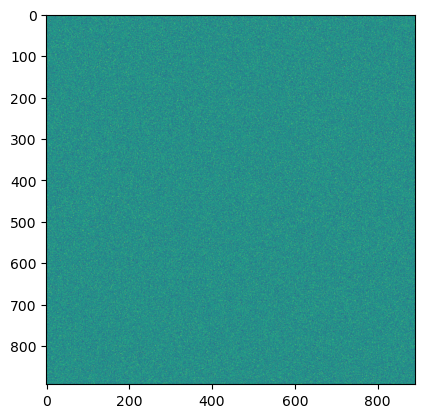

In [3]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
# Opening files and acessing data
map0 = fits.open('noisemap0.fits'); d0 = map0[0].data
map1 = fits.open('noisemap1.fits'); d1 = map1[0].data
map2 = fits.open('noisemap2.fits'); d2 = map2[0].data

# Standard deviation of noisemap 0 to 2
std0 = np.std(d0); print(f"Standard deviation of map 0: {std0}")
std1 = np.std(d1); print(f"Standard deviation of map 1: {std1}")
std2 = np.std(d2); print(f"Standard deviation of map 2: {std2}")

# Stacking the images
stack = np.stack((d0,d1,d2), axis = 0)  # Along z axis (0)

# Creating image of the mean of the three images
mn = np.mean(stack, axis = 0)  # Mean along z axis
plt.imshow(mn)

# Calculating the standard deviation for all pixels in mean image
std_img = np.std(mn)
print(f"Standard deviation of pixels in image: {std_img}")

# Calculating noise with formula
N = 3
sgm = (1/N) * np.sqrt((std0**2)+(std1**2)+(std2**2))
print(sgm)

# The function value for the standard deviation is almost the same as the one calculated with the formula

map0.close(); map1.close(); map1.close()

### 6.6 (unchecked)

In [2]:
from astropy.io import fits
from astropy.table import Table
import numpy as np


# Open the FITS file
hdul = fits.open('APOGEE_stars (1).fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
# The biggest difference is the index while reading an image and a table. For an image you use the index 0 and for a table the index 1.
# The image gives the data directly, while the table gives the data dor each column

# Converting file to a table
table = Table(data)

# The flag for our new column
flag = ((data['STARFLAG'] == 0) & (data['ASPCAPFLAG'] == 0) & (data['SNR'] > 10) & (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
(~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) & (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) & (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG'])))  # ~ is for saying that something is not something

# Adding column to table
dataflag = flag.astype(int)  # Transforms True to 1 and False to 0
table['DATAFLAG'] = dataflag  # Adds the column DATAFLAG and looks whether the value should be 1 or 0

# Accessing the apparent magnitude table
m = table['GAIAEDR3_PHOT_G_MEAN_MAG']
p = table['GAIAEDR3_PARALLAX']

# Calculating the absolute magnitude
valid_p = p > 0  # Creating a mask
abs_mag = np.full(len(p), -1.0)  # Creates a full array of the length of p filled with -1.0
abs_mag[valid_p] = m[valid_p] - 5 * np.log10(p[valid_p]/1000) + 5  # Calculating the absolute magnitude for only the values that the absolute magnitude can be calculated
table['ABSOLUTE_MAG'] = np.where(table['DATAFLAG'] == 1, abs_mag, -1.0)  # Adds the values for the absoulte magnitude to the table, only when dataflag is 1, else it puts -1.0

# Creating a FITS file called APOGEE_update.fits
table.write('APOGEE_update.fits', format = 'fits', overwrite = True)  # Creating a new fits file called APOGEE_update.fits

# Printing the newly created column
print(table['ABSOLUTE_MAG'])
print(table['DATAFLAG'])

   ABSOLUTE_MAG   
------------------
              -1.0
              -1.0
              -1.0
              -1.0
31.653636932373047
              -1.0
               ...
              -1.0
              -1.0
              -1.0
              -1.0
              -1.0
              -1.0
              -1.0
Length = 733901 rows
DATAFLAG
--------
       0
       0
       0
       0
       1
       0
     ...
       0
       0
       0
       0
       0
       0
       0
Length = 733901 rows


### 6.7 (unchecked)

The maximum value of the column 'phot_g_mean_flux': 42489404.0
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


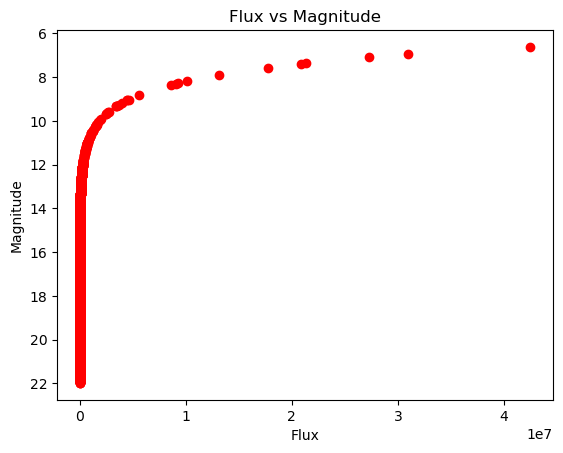

The mean of the relation is: 25.68840037029544


In [4]:
import pandas as pd
import numpy as np
from matplotlib.pyplot import *

data = pd.read_csv('gaiaTestData.csv')  # Opening csv file
gmf = data['phot_g_mean_flux']  # Obtaining the column 'phot_g_mean_flux'
max = np.max(gmf)  # Calculating max of the obtained column
print(f"The maximum value of the column 'phot_g_mean_flux': {max}") 

index = data[data['phot_g_mean_flux'] == np.max(gmf)]  # Finding index of the max and obtaining the whole row of that index
print(index)

# Data sorting and OOP
sorted = data.sort_values(by = 'phot_g_mean_flux', ascending = True)
fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(sorted['phot_g_mean_flux'], sorted['phot_g_mean_mag'], c = 'red')
frame.set_title('Flux vs Magnitude')
frame.set_ylabel('Magnitude')
frame.set_xlabel('Flux')
frame.invert_yaxis()
show()

# Calculating m0
m0 = sorted['phot_g_mean_mag'] + 2.5 * np.log10(sorted['phot_g_mean_flux'])  # Calculating relation
mean = np.mean(m0)  # Finding the mean of the calculated values
print(f"The mean of the relation is: {mean}")  


### 6.10 (unchecked)

In [6]:
from astroquery.gaia import Gaia
import pandas as pd 
from astropy.table import *

# Creating the conditions
query = """
SELECT TOP 50
    source_id, ra, dec, parallax, parallax_error, 
    phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax/parallax_error > 5
  AND phot_g_mean_mag IS NOT NULL
  AND phot_bp_mean_mag IS NOT NULL
  AND phot_rp_mean_mag IS NOT NULL
"""

# Executing and converting to pandas
job = Gaia.launch_job(query)
results = job.get_results()
gaia = results.to_pandas()
print(gaia.head())

# Converting to a FITS file
results.write('astroquery_gaia.fits', format = 'fits', overwrite=True)

The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive
        SOURCE_ID         ra       dec  parallax  parallax_error  \
0   7421703656704  45.023467  0.211892  2.246325        0.275147   
1   7460358480640  45.040351  0.221915  4.102116        0.538663   
2  13816910627200  45.120806  0.276415  0.613684        0.087399   
3  16222092310144  45.200011  0.370253  2.831291        0.039360   
4  16870631694208  45.112778  0.380840  2.101317        0.017279   

   phot_g_mean_mag  phot_bp_mean_mag  phot_rp_mean_mag  
0        19.161352         20.643721         18.044706  
1        20.100655         21.387501         18.819162  
2        17.208853         17.807318         16.488983  
3  

### 6.14 (unchecked)

In [5]:
class Fibonacci:
    """Class for calculating Fibonacci sequence"""
    
    def __init__(self, N, M):
        """Initializing"""
        self.N = N
        self.M = M
        
    def fib_sequence(self):
        """Finds the Nth term of the Fibonacci sequence"""
        fibo = [0, 1]
        for i in range(1000):
            fibo.append(fibo[-1] + fibo[-2])
        return f"The {self.N}th term in the sequence is: {fibo[self.N]}"
        
    def lesser(self):
        """Finds all terms less than N that can be divided by M"""
        fibo = [0, 1]
        result = []
        while len(fibo) < self.N:
            if fibo[-1] % self.M == 0:
                result.append(fibo[-1])
            fibo.append(fibo[-1] + fibo[-2])
        if self.N > 0 and 0 % self.M == 0:
            result.insert(0, 0)
        return f"All Fibonacci numbers less than the {self.N}th term that can be divided by {self.M} are: {result}"
            
        
fib = Fibonacci(100, 7)
print(fib.fib_sequence())
print(fib.lesser())

The 100th term in the sequence is: 354224848179261915075
All Fibonacci numbers less than the 100th term that can be divided by 7 are: [0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
